# Calibrating exhumation magnitude (and other parameters)

PyBasin's built-in multiple-model-run machinery (the `ParameterRanges`
class and the `_s` suffix convention, see the manual) runs a fixed,
hand-picked list of scenarios and is meant for sensitivity analysis. This
notebook instead demonstrates a small, flexible calibration harness
(`lib/calibration.py`) that runs one model scenario at a time with a chosen
parameter value, so a grid search (or any other search strategy) can decide
which values to try based on the goodness of fit of previous runs.

We calibrate the magnitude of the single exhumation phase
(`exhumed_thicknesses`) in `example_dataset_2` (a surface outcrop sample,
E40, from the Molasse Basin, which only simulates apatite (U-Th)/He ages)
against the measured (U-Th)/He age. The same approach works for
`example_dataset_1` or any other input dataset, and for any other scalar or
array parameter in `pybasin_params.py`, not just `exhumed_thicknesses`; the
last section shows this explicitly for a different parameter.


## Setup

In [1]:
import os
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import lib.calibration as calib

dataset_name = "example_dataset_2"

# calibration runs many model scenarios in a row; keep the screen output
# to warnings only so the notebook output stays readable. lib.calibration
# still returns the full goodness-of-fit statistics for every run.
logging.getLogger().setLevel(logging.WARNING)


INFO: fortran annealing module not found, using slower pure-python implementation (run "f2py -c calculate_reduced_AFT_lengths.f90 -m calculate_reduced_AFT_lengths" to speed this up)


INFO: fortran annealing module not found, using slower pure-python implementation (run "f2py -c calculate_reduced_AFT_lengths.f90 -m calculate_reduced_AFT_lengths" to speed this up)


## Choosing an objective

`lib.calibration.run_single_scenario()` returns a dict with, among others,
`he_age_gof` (goodness of fit, 1 = perfect, 0 = outside the measured
uncertainty range) and `he_age_error` (mean absolute difference between
modelled and measured age, in Myr). Let's check both for the dataset's
default exhumed thickness of 3000 m before deciding which to calibrate
against.


In [2]:
baseline = calib.run_single_scenario(dataset_name)
print(f"default exhumed_thicknesses = 3000 m: he_age_gof = {baseline['he_age_gof']:.2e}, "
     f"he_age_error = {baseline['he_age_error']:.2f} Myr")


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


default exhumed_thicknesses = 3000 m: he_age_gof = 4.43e-36, he_age_error = 2.84 Myr


The measured (U-Th)/He uncertainty in this example is small enough that
`he_age_gof` is essentially zero (a vanishing Gaussian tail probability) for
every exhumation magnitude in a reasonable range, so it has no useful
dynamic range to calibrate against here. `he_age_error`, the plain mean
absolute age misfit in million years, does vary meaningfully with
exhumation magnitude, so we minimize that instead. This is a useful general
lesson: always check that the metric you plan to calibrate against actually
varies over the range of parameter values you intend to explore.


## Grid search over exhumed thickness

A grid search is used rather than a gradient-based optimizer because the
goodness-of-fit surface of a burial and thermal history model can be
non-smooth (the model uses discrete stratigraphic and time steps), so a
plain scan is more robust than trusting a local derivative. This cell tries
exhumed thicknesses from 500 to 10 000 m; each model run takes a few
seconds, so the full grid takes a few minutes.


In [3]:
values = [np.array([v]) for v in np.arange(500.0, 10001.0, 500.0)]

grid_df = calib.grid_search(
    dataset_name,
    param_name="exhumed_thicknesses",
    values=values,
    metric="he_age_error",
    maximize=False,
)

# store the plain magnitude (not the 1-element array) for plotting
grid_df["exhumed_thickness_m"] = [v[0] for v in grid_df["value"]]

best_thickness = grid_df.attrs["best_value"][0]
best_error = grid_df.attrs["best_he_age_error"]
print(f"best-fitting exhumed thickness: {best_thickness:.0f} m "
     f"(he_age_error = {best_error:.2f} Myr)")


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


...

----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


best-fitting exhumed thickness: 6500 m (he_age_error = 1.66 Myr)


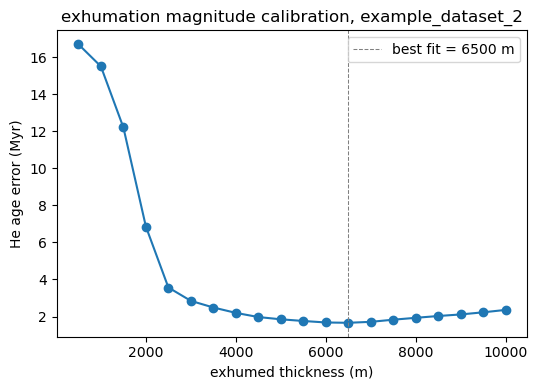

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(grid_df["exhumed_thickness_m"], grid_df["he_age_error"], "o-")
ax.axvline(best_thickness, color="grey", ls="--", lw=0.75,
          label=f"best fit = {best_thickness:.0f} m")
ax.set_xlabel("exhumed thickness (m)")
ax.set_ylabel("He age error (Myr)")
ax.set_title(f"exhumation magnitude calibration, {dataset_name}")
ax.legend()
fig.tight_layout()


## Refining the grid search optimum

The grid above only samples every 500 m. `scipy.optimize.minimize_scalar`
can refine the estimate within a bounded interval around the grid optimum,
using many fewer model runs than a finer grid would need. Because the
underlying model is not guaranteed to be perfectly smooth, this is offered
as an optional refinement of the grid search result, not a replacement for
it: always sanity-check a gradient-based result against the coarser grid
(the two should agree closely, as they do here).


In [5]:
from scipy.optimize import minimize_scalar

def objective(thickness):
    try:
        result = calib.run_single_scenario(
            dataset_name,
            param_overrides={"exhumed_thicknesses": np.array([thickness])},
        )
        return result["he_age_error"]
    except Exception as e:
        # an infeasible parameter value (eg. an inconsistent exhumation
        # timing) should not crash the optimizer; penalize it instead so
        # the search moves away from that region
        print(f"exhumed_thicknesses = {thickness:.0f} m failed ({e}); penalizing")
        return 1e6

# bracket the refinement around the two grid points either side of the optimum
i_best = grid_df["he_age_error"].idxmin()
lo = grid_df["exhumed_thickness_m"].iloc[max(i_best - 1, 0)]
hi = grid_df["exhumed_thickness_m"].iloc[min(i_best + 1, len(grid_df) - 1)]

refined = minimize_scalar(objective, bounds=(lo, hi), method="bounded",
                          options={"xatol": 10.0})
print(f"refined best-fitting exhumed thickness: {refined.x:.0f} m "
     f"(he_age_error = {refined.fun:.2f} Myr)")


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


...

----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


refined best-fitting exhumed thickness: 6331 m (he_age_error = 1.65 Myr)


## Calibrating a different parameter

The same `run_single_scenario()` / `grid_search()` functions work for any
`ModelParameters` attribute, not just `exhumed_thicknesses`. As a second,
quick example, this scans the age at which exhumation started
(`exhumation_period_starts`), holding the exhumed thickness fixed at the
refined value found above, to show how an additional parameter can be
added to the same calibration without writing any new plumbing.


In [6]:
start_age_values = [np.array([v]) for v in [8.0, 10.0, 12.0, 14.0, 16.0]]

start_age_df = calib.grid_search(
    dataset_name,
    param_name="exhumation_period_starts",
    values=start_age_values,
    metric="he_age_error",
    maximize=False,
    fixed_overrides={"exhumed_thicknesses": np.array([refined.x])},
)
start_age_df["exhumation_start_ma"] = [v[0] for v in start_age_df["value"]]
start_age_df[["exhumation_start_ma", "he_age_error"]]


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


	age and duration of each timeslice (My):
	age of timeslice = 13.782 - 13.885, duration = -0.103
	age of timeslice = 13.564 - 13.620, duration = -0.056
	age of timeslice = 13.346 - 13.443, duration = -0.097
	age of timeslice = 13.128 - 13.177, duration = -0.049
	age of timeslice = 12.910 - 13.000, duration = -0.090



----------
Example PyBasin dataset from the Molasse Basin (von Hagke et al. 2012)
----------


	age and duration of each timeslice (My):
	age of timeslice = 15.751 - 15.833, duration = -0.082
	age of timeslice = 15.502 - 15.656, duration = -0.154
	age of timeslice = 15.253 - 15.391, duration = -0.138
	age of timeslice = 15.004 - 15.125, duration = -0.121
	age of timeslice = 14.755 - 14.859, duration = -0.105
	age of timeslice = 14.505 - 14.594, duration = -0.088
	age of timeslice = 14.256 - 14.417, duration = -0.160
	age of timeslice = 14.007 - 14.151, duration = -0.144
	age of timeslice = 13.758 - 13.885, duration = -0.127
	age of timeslice = 13.509 - 13.620, duration = -0.111
	age of timeslice = 13.260 - 13.354, duration = -0.094
	age of timeslice = 13.011 - 13.089, duration = -0.078



,exhumation_start_ma,he_age_error
0,8.0,2.337427
1,10.0,1.885991
2,12.0,1.653368
3,14.0,NaN
4,16.0,NaN


Two of the five values tried (14 and 16 Ma) show up as `NaN`: for this
combination of exhumed thickness and exhumation start age, the resulting
stratigraphy contains a geological timestep with a negative duration, which
`run_burial_hist_model` rejects. This is exactly the kind of infeasible
parameter combination `grid_search()` is meant to survive: it logs a
warning and records `NaN` for that value instead of crashing the whole
scan, so the three feasible values (8, 10 and 12 Ma) are still usable. The
error decreases monotonically from 8 to 12 Ma, so the best fit found here
sits at the edge of the range that is both geologically feasible and
tested; a finer or wider grid would be needed to tell whether 12 Ma is a
true optimum or just the last feasible point.


## Summary

Refit vs. the dataset's default parameters:


In [7]:
summary = pd.DataFrame({
    "exhumed_thickness_m": [3000.0, refined.x],
    "he_age_error_Myr": [baseline["he_age_error"], refined.fun],
}, index=["default (pybasin_params.py)", "calibrated"])
summary


,exhumed_thickness_m,he_age_error_Myr
default (pybasin_params.py),3000.000000,2.844605
calibrated,6330.898431,1.653368


**What this result does and does not show.** The calibrated thickness
above (about 6300-6500 m) is a demonstration of the calibration mechanics
on a single (U-Th)/He sample with a small measurement uncertainty, not a
recommended exhumation estimate for the Molasse Basin: a real calibration
would use several samples and data types (eg. also apatite fission track
ages, as in `example_dataset_1`), and would propagate parameter and data
uncertainty into the result rather than reporting a single best-fit value.
The point of this notebook is that `lib/calibration.py` makes it
straightforward to try that, for `exhumed_thicknesses` or any other
parameter, without writing new plumbing for each one.
